# Examen des règles complexes

## Objectif pédagogique

Ce notebook transforme le concept EBTA des **règles complexes** en une illustration pratique orientée **trading quantitatif** et **backtest**.

L’idée centrale est simple :

> Une règle simple peut être trop pauvre pour capturer un marché complexe. Une règle complexe combine plusieurs signaux pour augmenter la quantité d'information exploitable, mais elle augmente aussi le risque de **data mining bias** et d’**overfitting**.

Dans ce notebook, on va construire trois familles de modèles :

- une règle simple isolée ;
- une règle complexe par **vote majoritaire** ;
- une règle complexe par **position fractionnée**.

Puis on ajoutera une mini-correction de type **test par permutation** pour illustrer pourquoi la performance brute ne suffit jamais.

## 1. Intuition EBTA

Une règle technique simple répond souvent à une seule question :

- le prix est-il au-dessus de sa moyenne mobile ?
- le RSI est-il survendu ?
- le momentum est-il positif ?
- le volume confirme-t-il le mouvement ?

Mais le marché est rarement gouverné par une seule dimension.

Une **règle complexe** tente de condenser plusieurs angles d'information.

| Source d'information | Question posée |
|---|---|
| Momentum | Le prix accélère-t-il ? |
| Tendance | Le prix suit-il une direction persistante ? |
| Mean reversion | Le prix est-il excessivement éloigné de sa moyenne ? |
| Volume | Le mouvement est-il confirmé par l'activité ? |
| Volatilité | Le contexte est-il calme ou explosif ? |

> L’enjeu n’est pas d’ajouter des indicateurs au hasard.  
> L’enjeu est de combiner des signaux qui apportent une **information incrémentale**.

## 2. Loi de variété requise d’Ashby appliquée au trading

La loi de variété requise dit qu’un système de contrôle doit avoir assez de variété interne pour répondre à la variété du système qu’il tente de contrôler ou de prédire.

Application trading :

> Un marché complexe, changeant, bruité et multi-régime ne peut pas être correctement capturé par une règle trop pauvre.

Cela ne veut pas dire :

> “Plus c’est complexe, mieux c’est.”

Cela veut dire :

> “La complexité doit être suffisante pour représenter le problème, mais pas excessive au point d’apprendre le bruit.”

C’est exactement la tension centrale de l’EBTA.

| Besoin | Danger |
|---|---|
| Augmenter la capacité informative du modèle | Surapprendre le passé |
| Combiner plusieurs signaux | Multiplier les degrés de liberté |
| Capturer des interactions non-linéaires | Agrandir l’univers de data mining |
| Améliorer la prédiction | Réduire la robustesse OOS |

## 3. Setup Python

On va générer une série de prix synthétique avec plusieurs régimes :

- régime haussier ;
- régime baissier ;
- régime neutre/bruité.

Ce n’est pas un vrai actif financier. Le but est pédagogique : montrer comment construire et comparer des règles complexes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 1_000
dates = pd.date_range("2020-01-01", periods=n, freq="D")

# Régimes synthétiques : drift variable dans le temps
drift = np.zeros(n)
drift[:300] = 0.0006      # tendance haussière
drift[300:650] = -0.0004  # tendance baissière
drift[650:] = 0.0002      # régime légèrement haussier

noise = np.random.normal(0, 0.01, n)
returns = drift + noise

price = 100 * np.exp(np.cumsum(returns))

data = pd.DataFrame({
    "close": price,
    "returns": returns
}, index=dates)

data.head()

,close,returns
2020-01-01,100.558267,0.005567
2020-01-02,100.479596,-0.000783
2020-01-03,101.193201,0.007077
2020-01-04,102.807866,0.015830
2020-01-05,102.628979,-0.001742


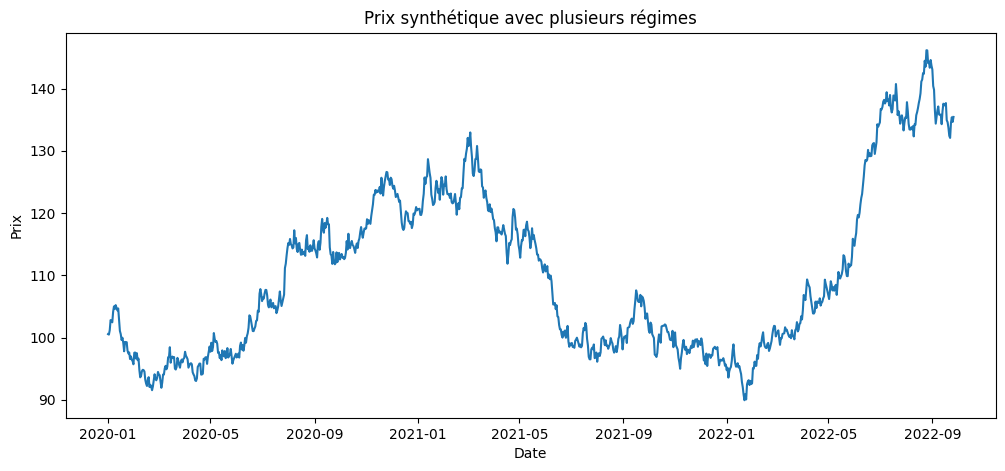

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["close"])
plt.title("Prix synthétique avec plusieurs régimes")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

## 4. Construire plusieurs règles simples

On crée quatre règles simples :

1. **Momentum court terme** : rendement sur 10 jours positif ou négatif.
2. **Tendance moyenne mobile** : prix au-dessus ou en dessous de sa moyenne mobile 50 jours.
3. **Mean reversion** : prix éloigné de sa moyenne mobile 20 jours.
4. **Breakout** : prix proche de son plus haut ou de son plus bas 60 jours.

Chaque règle renvoie :

$$
+1 = \text{long}
$$

$$
-1 = \text{short}
$$

$$
0 = \text{neutre}
$$

In [3]:
def sign(x):
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))

df = data.copy()

# 1. Momentum 10 jours
df["mom_10"] = df["close"].pct_change(10)
df["signal_momentum"] = sign(df["mom_10"])

# 2. Tendance MA 50
df["ma_50"] = df["close"].rolling(50).mean()
df["signal_trend"] = sign(df["close"] - df["ma_50"])

# 3. Mean reversion autour de MA 20
df["ma_20"] = df["close"].rolling(20).mean()
df["z_distance"] = (df["close"] - df["ma_20"]) / df["close"].rolling(20).std()

# Si le prix est très haut vs moyenne, on short ; très bas, on long
df["signal_reversion"] = np.where(
    df["z_distance"] > 1.0, -1,
    np.where(df["z_distance"] < -1.0, 1, 0)
)

# 4. Breakout 60 jours
df["high_60"] = df["close"].rolling(60).max()
df["low_60"] = df["close"].rolling(60).min()
df["signal_breakout"] = np.where(
    df["close"] >= df["high_60"].shift(1), 1,
    np.where(df["close"] <= df["low_60"].shift(1), -1, 0)
)

signal_cols = [
    "signal_momentum",
    "signal_trend",
    "signal_reversion",
    "signal_breakout"
]

df[signal_cols].tail()

,signal_momentum,signal_trend,signal_reversion,signal_breakout
2022-09-22,-1,-1,1,-1
2022-09-23,-1,-1,0,0
2022-09-24,-1,-1,0,0
2022-09-25,-1,-1,0,0
2022-09-26,-1,-1,0,0


## 5. Backtest minimaliste d’une règle

Important : pour éviter le **look-ahead bias**, la position utilisée pour le rendement du jour $t$ doit être décidée avec l'information disponible avant ce rendement.

On applique donc :

$$
\text{strategy return}_t = \text{position}_{t-1} \times \text{return}_t
$$

In [4]:
def backtest_from_position(dataframe, position_col, cost_bps=0.0):
    '''
    Backtest vectorisé minimaliste.

    - position_col contient la position cible : -1, 0 ou +1.
    - La position est décalée d'un jour pour éviter le look-ahead bias.
    - cost_bps applique un coût sur les changements de position.
    '''
    out = dataframe.copy()
    position = out[position_col].fillna(0).clip(-1, 1)
    executed_position = position.shift(1).fillna(0)

    turnover = executed_position.diff().abs().fillna(0)
    costs = turnover * (cost_bps / 10_000)

    out[f"ret_{position_col}"] = executed_position * out["returns"] - costs
    out[f"equity_{position_col}"] = (1 + out[f"ret_{position_col}"]).cumprod()

    return out

def performance_summary(returns, periods_per_year=252):
    returns = returns.dropna()

    if returns.std() == 0:
        sharpe = np.nan
    else:
        sharpe = np.sqrt(periods_per_year) * returns.mean() / returns.std()

    equity = (1 + returns).cumprod()
    max_dd = (equity / equity.cummax() - 1).min()

    return pd.Series({
        "Total Return": equity.iloc[-1] - 1,
        "Annualized Return": returns.mean() * periods_per_year,
        "Annualized Vol": returns.std() * np.sqrt(periods_per_year),
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Nb Days": len(returns)
    })

In [5]:
# Backtest des règles simples
results = {}

bt = df.copy()
for col in signal_cols:
    bt = backtest_from_position(bt, col, cost_bps=1.0)
    results[col] = performance_summary(bt[f"ret_{col}"])

simple_results = pd.DataFrame(results).T
simple_results

,Total Return,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Nb Days
signal_momentum,-0.217716,-0.049851,0.155111,-0.321387,-0.310261,1000.0
signal_trend,0.105594,0.036850,0.152104,0.242268,-0.209438,1000.0
signal_reversion,-0.232582,-0.060315,0.112977,-0.533868,-0.299868,1000.0
signal_breakout,0.094195,0.024296,0.056833,0.427507,-0.051631,1000.0


## 6. Règle complexe n°1 : vote majoritaire

La règle de vote majoritaire agrège les signaux simples.

Formule :

$$
\text{position}_t = \text{sign}\left(\sum_{i=1}^{N} s_{i,t}\right)
$$

où $s_{i,t}$ est le signal de la règle simple $i$ au temps $t$.

In [6]:
df["signal_vote"] = sign(df[signal_cols].sum(axis=1))

bt = backtest_from_position(df, "signal_vote", cost_bps=1.0)
vote_perf = performance_summary(bt["ret_signal_vote"])
vote_perf

Total Return           -0.071116
Annualized Return      -0.008811
Annualized Vol          0.139928
Sharpe                 -0.062972
Max Drawdown           -0.222530
Nb Days              1000.000000
dtype: float64

## 7. Règle complexe n°2 : position fractionnée

La position fractionnée ne force pas un signal binaire.

Elle ajuste l'exposition selon le consensus net des règles.

Formule :

$$
\text{position}_t = \frac{1}{N}\sum_{i=1}^{N} s_{i,t}
$$

Exemple :

- 3 signaux long, 1 signal short :

$$
\text{position} = \frac{3 - 1}{4} = 0.50
$$

Cette approche peut réduire le turnover et lisser le risque.

In [7]:
df["signal_fractional"] = df[signal_cols].mean(axis=1)

bt = backtest_from_position(df, "signal_fractional", cost_bps=1.0)
fractional_perf = performance_summary(bt["ret_signal_fractional"])
fractional_perf

Total Return           -0.049016
Annualized Return      -0.011121
Annualized Vol          0.055589
Sharpe                 -0.200052
Max Drawdown           -0.119385
Nb Days              1000.000000
dtype: float64

In [8]:
all_results = simple_results.copy()
all_results.loc["complex_vote"] = vote_perf
all_results.loc["complex_fractional"] = fractional_perf

all_results.sort_values("Sharpe", ascending=False)

,Total Return,Annualized Return,Annualized Vol,Sharpe,Max Drawdown,Nb Days
signal_breakout,0.094195,0.024296,0.056833,0.427507,-0.051631,1000.0
signal_trend,0.105594,0.036850,0.152104,0.242268,-0.209438,1000.0
complex_vote,-0.071116,-0.008811,0.139928,-0.062972,-0.222530,1000.0
complex_fractional,-0.049016,-0.011121,0.055589,-0.200052,-0.119385,1000.0
signal_momentum,-0.217716,-0.049851,0.155111,-0.321387,-0.310261,1000.0
signal_reversion,-0.232582,-0.060315,0.112977,-0.533868,-0.299868,1000.0


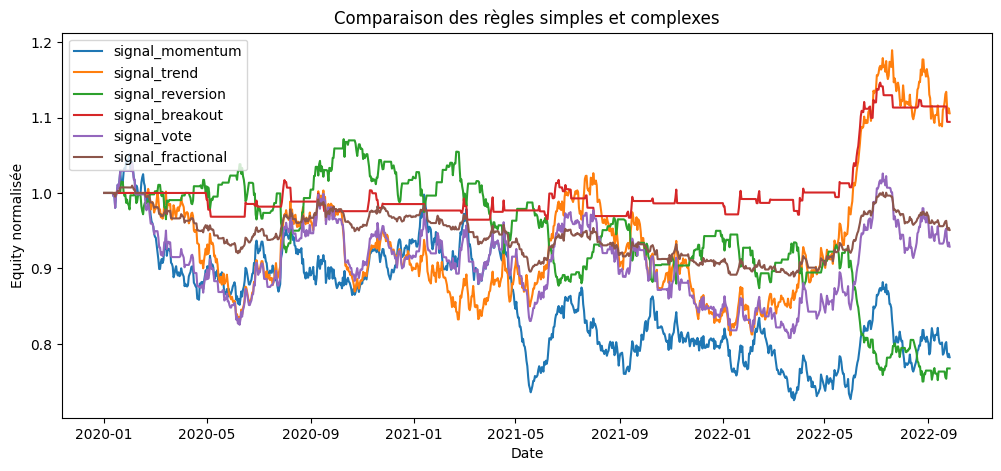

In [9]:
plt.figure(figsize=(12, 5))

bt_compare = df.copy()

for col in signal_cols + ["signal_vote", "signal_fractional"]:
    bt_compare = backtest_from_position(bt_compare, col, cost_bps=1.0)
    equity_col = f"equity_{col}"
    plt.plot(bt_compare.index, bt_compare[equity_col], label=col)

plt.title("Comparaison des règles simples et complexes")
plt.xlabel("Date")
plt.ylabel("Equity normalisée")
plt.legend()
plt.show()

## 8. Lecture EBTA des résultats

Une règle complexe peut battre les règles simples pour trois raisons :

1. Elle **diversifie les sources d'information**.
2. Elle réduit la dépendance à un seul indicateur.
3. Elle peut capturer des contextes où plusieurs signaux faibles deviennent collectivement utiles.

Mais attention :

> Une meilleure performance in-sample ne prouve rien si l’univers de recherche est large.

Si tu testes :

- 100 variantes de momentum ;
- 200 variantes de moyennes mobiles ;
- 50 variantes de RSI ;
- 20 méthodes de vote ;
- 10 pondérations différentes ;

alors tu n’as pas testé une stratégie.

Tu as testé un **univers de stratégies**.

Et dans l’EBTA, l’unité statistique correcte devient l’univers complet des règles candidates, pas seulement la règle gagnante.

## 9. Illustration du data mining bias

On va créer un mini-univers de règles complexes en faisant varier les pondérations des quatre signaux.

Le but n'est pas d'optimiser sérieusement, mais de montrer le piège :

> Plus tu testes de combinaisons, plus tu augmentes la probabilité de trouver une bonne performance par hasard.

In [10]:
from itertools import product

candidate_results = []

weights_grid = [-1, 0, 1, 2]

for weights in product(weights_grid, repeat=len(signal_cols)):
    weights = np.array(weights)

    # On ignore le cas où tous les poids sont nuls
    if np.all(weights == 0):
        continue

    raw_score = df[signal_cols].fillna(0).values @ weights
    candidate_signal = sign(raw_score)

    temp = df.copy()
    temp["candidate_signal"] = candidate_signal

    temp_bt = backtest_from_position(temp, "candidate_signal", cost_bps=1.0)
    perf = performance_summary(temp_bt["ret_candidate_signal"])

    candidate_results.append({
        "weights": tuple(weights),
        "Sharpe": perf["Sharpe"],
        "Total Return": perf["Total Return"],
        "Max Drawdown": perf["Max Drawdown"]
    })

candidates = pd.DataFrame(candidate_results)
candidates.sort_values("Sharpe", ascending=False).head(10)

,weights,Sharpe,Total Return,Max Drawdown
18,"(-1, 0, -1, 1)",0.898291,0.494960,-0.182726
19,"(-1, 0, -1, 2)",0.898291,0.494960,-0.182726
17,"(-1, 0, -1, 0)",0.787576,0.365170,-0.152728
33,"(-1, 1, -1, 0)",0.698903,0.386977,-0.176882
35,"(-1, 1, -1, 2)",0.698903,0.386977,-0.176882
34,"(-1, 1, -1, 1)",0.698903,0.386977,-0.176882
38,"(-1, 1, 0, 1)",0.633838,0.254863,-0.141559
39,"(-1, 1, 0, 2)",0.633838,0.254863,-0.141559
23,"(-1, 0, 0, 2)",0.545695,0.333733,-0.208327
32,"(-1, 1, -1, -1)",0.521261,0.239757,-0.161370


## 10. Mini-test par permutation

On veut tester une idée simple :

> Si les signaux n'ont aucun pouvoir prédictif réel, quelle performance maximale pourrait-on obtenir simplement par hasard dans le même univers de règles ?

On va mélanger les rendements pour casser le lien temporel entre signal et rendement, puis recalculer le meilleur Sharpe obtenu dans l’univers de règles.

Ce n’est pas une implémentation complète du **White’s Reality Check**, mais c’est une intuition utile.

In [11]:
def best_sharpe_for_returns(input_returns, signals_matrix, weights_grid=(-1, 0, 1, 2)):
    best_sharpe = -np.inf

    temp_df = pd.DataFrame({
        "returns": input_returns
    })

    for weights in product(weights_grid, repeat=signals_matrix.shape[1]):
        weights = np.array(weights)

        if np.all(weights == 0):
            continue

        raw_score = signals_matrix @ weights
        candidate_signal = sign(raw_score)

        temp_df["candidate_signal"] = candidate_signal
        tested = backtest_from_position(temp_df, "candidate_signal", cost_bps=1.0)
        sharpe = performance_summary(tested["ret_candidate_signal"])["Sharpe"]

        if sharpe > best_sharpe:
            best_sharpe = sharpe

    return best_sharpe

signals_matrix = df[signal_cols].fillna(0).values
observed_best_sharpe = candidates["Sharpe"].max()

n_permutations = 200
null_best_sharpes = []

for _ in range(n_permutations):
    shuffled_returns = np.random.permutation(df["returns"].values)
    null_best = best_sharpe_for_returns(shuffled_returns, signals_matrix)
    null_best_sharpes.append(null_best)

null_best_sharpes = np.array(null_best_sharpes)

p_value = np.mean(null_best_sharpes >= observed_best_sharpe)

observed_best_sharpe, p_value

(np.float64(0.8982910477682101), np.float64(0.45))

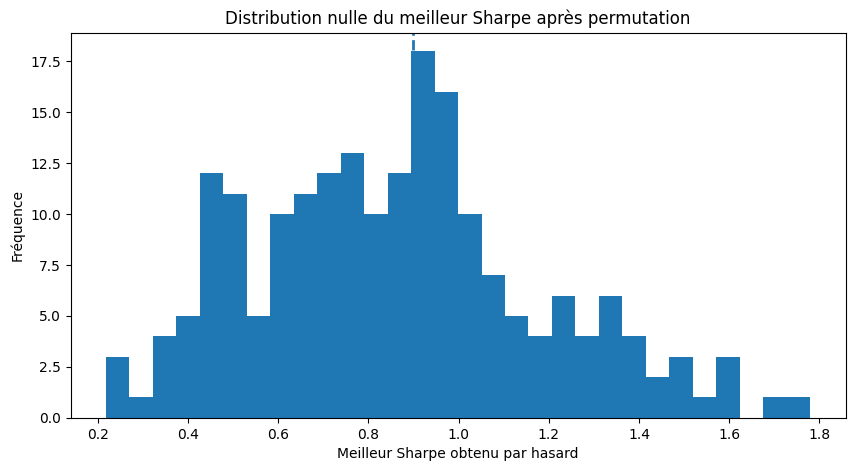

Meilleur Sharpe observé : 0.90
p-value empirique approximative : 0.450


In [12]:
plt.figure(figsize=(10, 5))
plt.hist(null_best_sharpes, bins=30)
plt.axvline(observed_best_sharpe, linestyle="--", linewidth=2)
plt.title("Distribution nulle du meilleur Sharpe après permutation")
plt.xlabel("Meilleur Sharpe obtenu par hasard")
plt.ylabel("Fréquence")
plt.show()

print(f"Meilleur Sharpe observé : {observed_best_sharpe:.2f}")
print(f"p-value empirique approximative : {p_value:.3f}")

## 11. Interprétation

La question EBTA n’est pas :

> “La meilleure règle complexe a-t-elle gagné de l'argent ?”

La vraie question est :

> “La meilleure règle complexe a-t-elle fait mieux que ce qu’un processus aléatoire aurait pu produire après avoir testé autant de variantes ?”

C’est précisément la logique derrière les méthodes comme :

- **White’s Reality Check** ;
- **MCPM** ;
- corrections de type **Romano-Wolf** ;
- validation **Train / Test / Validation OOS**.

Une règle complexe n’échappe pas au châtiment statistique.

Au contraire :

> Plus la règle est complexe, plus la validation doit être stricte.

## 12. Guide opérationnel pour ton pipeline EBTA

### Phase Train

Objectif : construire l’univers des règles candidates.

À faire :

- définir les familles de signaux ;
- justifier chaque signal par une logique comportementale, économique ou microstructurelle ;
- créer les variantes de paramètres ;
- créer les méthodes de combinaison : vote, fractionnel, pondéré, non-linéaire ;
- enregistrer toutes les règles testées.

À éviter :

- supprimer discrètement les règles perdantes ;
- modifier l’univers après avoir vu les résultats ;
- ne garder que la meilleure règle dans les logs.

### Phase Test

Objectif : sélectionner une règle tout en corrigeant le **data mining bias**.

À faire :

- tester tout l’univers candidat ;
- appliquer une correction type WRC, MCPM ou équivalent ;
- sélectionner uniquement une règle statistiquement défendable ;
- mesurer si le meilleur candidat bat réellement le hasard conditionnellement à l’univers testé.

À éviter :

- faire une p-value classique sur la seule règle gagnante ;
- oublier les variantes explorées ;
- multiplier les essais jusqu’à obtenir une p-value acceptable.

### Phase Validation OOS

Objectif : vérifier le comportement réaliste de la règle finalisée.

À faire :

- tester une seule règle verrouillée ;
- ne plus optimiser ;
- observer la stabilité du rendement, du drawdown, du turnover et du comportement par régime ;
- décider si la règle mérite incubation ou abandon.

À éviter :

- retoucher la stratégie après avoir vu l’OOS ;
- transformer la validation en nouveau train ;
- refaire une boucle infinie d’ajustement.

## 13. Eurêka final

> La complexité est utile seulement si elle augmente l’information plus vite qu’elle n’augmente le risque d’overfitting.

Dans une logique EBTA, tu ne cherches pas une règle complexe parce qu’elle “semble plus intelligente”.

Tu la cherches parce que :

- le marché est multi-régime ;
- les signaux simples sont informationnellement faibles ;
- la combinaison peut créer une synergie ;
- mais cette synergie doit survivre au hasard, au data mining, aux coûts et à l’OOS.

La règle complexe est donc une arme puissante, mais dangereuse.

> Elle doit être construite comme un modèle scientifique, pas comme un cocktail d’indicateurs.

## 14. Checklist pratique

| Question | Réponse attendue |
|---|---|
| Ai-je une raison d’ajouter ce signal ? | Oui, logique claire |
| Ce signal apporte-t-il une information différente ? | Oui, faible redondance |
| Ai-je enregistré toutes les variantes testées ? | Oui |
| Ai-je corrigé le data mining bias ? | Oui |
| La règle complexe bat-elle les règles simples ? | Oui, après coûts |
| La règle survit-elle en OOS ? | Oui |
| La complexité est-elle justifiée ? | Oui |
| Puis-je expliquer le modèle simplement ? | Oui |

> Si tu ne peux pas expliquer pourquoi chaque bloc existe, le modèle est probablement trop complexe ou mal conçu.

## Annexe — Texte source fourni

# EXAMEN DES RÈGLES COMPLEXES

## Référence
*   **Titre exact :** *Consideration of Complex Rules*.
*   **Chapitre :** Chapitre 9 (Case Study Results and the Future of TA).
*   **Pages :** 452 – 455.
*   **Thème principal :** La supériorité théorique et empirique des modèles combinant plusieurs signaux pour capturer la complexité des marchés.

---

## Idées clés
1.  **Synergie informationnelle** — Les règles complexes combinent et condensent les informations de plusieurs règles simples, permettant une performance supérieure sur des problèmes de prédiction difficiles.
2.  **Loi de Variété Requise d'Ashby** — Un modèle prédictif doit avoir un degré de complexité équivalent au système qu'il tente de prédire ; les marchés financiers étant complexes, les modèles simples sont structurellement insuffisants.
3.  **Supériorité empirique démontrée** — Dans une étude sur près de 40 000 règles, 82 % de celles ayant généré des profits statistiquement significatifs étaient des règles complexes.
4.  **Combinaisons Linéaires vs Non-linéaires** — L'assemblage de règles peut se faire par de simples votes (linéaire) ou par des algorithmes d'apprentissage automatique (non-linéaires) pour extraire plus de valeur que la somme des parties.

---

## Citation directe
> “A nonlinear combination of simple rules allows the complex rule to be more informative than the summed information contained in its individual constituents. This allows the rule to comply with Ashby's Law of Requisite Variety.”

*Cette citation signifie qu'en combinant intelligemment des indicateurs, on obtient un modèle dont l'intelligence globale dépasse la simple addition des signaux. C'est cette complexité qui permet de faire face à la nature changeante et riche du marché.*

---

## Vision macro
L'enjeu de ce passage est de dépasser l'échec des 6 402 règles simples testées dans l'étude de cas d'Aronson. L'auteur reconnaît que l'analyse technique traditionnelle échoue souvent parce qu'elle cherche des solutions trop simples à un problème extrêmement complexe. Pour l'approche EBTA, l'avenir ne réside pas dans la découverte d'un "indicateur miracle" unique, mais dans l'ingénierie de modèles robustes capables d'intégrer des sources d'informations multiples et synergiques.

---

## Vision micro
Le passage détaille deux méthodes principales pour construire ces règles :

1.  **Combinaisons Linéaires (Simples) :**
    *   **Règles de vote (Voting rules) :** On consulte tous les indicateurs d'un thème. Si la majorité est à l'achat (+1), la règle complexe prend une position longue.
    *   **Positions fractionnées (Fractional positions) :** La taille de la position est proportionnelle au pourcentage net d'indicateurs signalant une direction (ex: si 60% sont acheteurs et 40% vendeurs, la position est de +0,20).

2.  **Combinaisons Non-linéaires (Avancées) :**
    *   Utilisation du **Machine Learning** (réseaux de neurones, arbres de décision, programmation génétique).
    *   Ces systèmes apprennent des relations complexes entre les indicateurs et les rendements futurs, identifiant des motifs que l'œil humain ou une somme arithmétique ne peuvent voir.

**Concept statistique clé : Loi de Variété Requise (Ashby).**
*   **Définition :** Un principe de cybernétique stipulant que pour réguler ou prédire un système, le contrôleur doit posséder autant de "variété" (états possibles) que le système lui-même.
*   **Intuition :** On ne peut pas prédire un ouragan (complexe) avec une simple girouette (trop simple). De même, on ne peut pas prédire le S&P 500 avec un seul RSI.

---

## Exemples du livre
*   **L'étude de Hsu et Kuan :** Ils ont testé 39 832 règles sur quatre indices (Dow, S&P 500, NASDAQ, Russell 2000). Résultat : sur les 229 règles jugées significatives (après correction du biais de data mining via le WRC), 188 étaient des règles complexes.
*   **L’exemple de l'On-Balance Volume (OBV) :** Hsu et Kuan ont utilisé 2 040 variantes de l'OBV. Dans leur système fractionné, si 1 158 règles étaient courtes et 882 longues, la position finale était une vente de 0,135 unité.
*   **L'analogie de l'équipe d'experts :** Aronson suggère qu'une règle complexe agit comme un comité d'experts où chaque règle simple apporte son point de vue.

---

## Résumé simplifié
Les règles de trading simples (comme un simple croisement de moyennes mobiles) sont souvent trop "bêtes" pour le marché. Aronson explique que pour gagner, il faut combiner plusieurs règles ensemble. C'est comme demander l'avis à 10 experts plutôt qu'à un seul. On peut soit faire un vote à la majorité (linéaire), soit utiliser l'intelligence artificielle pour trouver des liens cachés (non-linéaire). L'expérience montre que ce sont presque toujours ces mélanges complexes qui réussissent à battre le hasard.

---

## Actions concrètes
*   **Ce qu'il faut faire :** Privilégier le développement de modèles multi-indicateurs plutôt que de chercher le paramètre "parfait" d'un indicateur unique.
*   **Ce qu'il faut éviter :** Croire qu'une règle simple qui a échoué dans le passé peut être sauvée sans augmenter sa capacité informative.
*   **Ce qu'il faut mesurer :** Le gain de performance apporté par chaque nouvel indicateur ajouté au modèle complexe (incrément d'information).
*   **Ce qu'il faut tester :** Des schémas de vote et des pondérations fractionnées pour lisser le risque.

---

## Limites et erreurs fréquentes
### Limites
*   **Risque de Surapprentissage (Overfitting) :** Plus un modèle est complexe, plus il risque d'apprendre par cœur le "bruit" des données passées au lieu des vrais motifs.
*   **Besoin de données massives :** Les modèles complexes (ML) nécessitent beaucoup plus d'observations historiques pour être validés sans biais.

### Erreurs fréquentes
*   **Ignorer le châtiment du Data Mining :** Croire que parce qu'un modèle est complexe, il n'a pas besoin de subir le White's Reality Check. Au contraire, la complexité augmente l'espace de recherche et donc le biais.
*   **Complexité sans théorie :** Ajouter des indicateurs au hasard sans logique économique (ex: mélanger l'astrologie et le RSI).

---

## À retenir absolument
*   La **complexité est nécessaire** pour modéliser des marchés complexes.
*   Les **combinaisons de règles** sont statistiquement plus robustes que les règles isolées.
*   Le **Machine Learning** est l'outil privilégié pour créer ces synergies non-linéaires.
*   La **Loi d'Ashby** condamne l'analyse technique simpliste à l'échec.
*   Une règle complexe doit toujours être validée par un **protocole à trois segments** (Train/Test/Validation) pour éviter l'overfitting.

J'ai terminé l'analyse de l'examen des règles complexes selon le protocole EBTA.